# FIFA WORLD CUP PLAYER PERFORMANCE ANALYTICS

### Phase 1 : Import Libraries

In [2]:
import pandas as pd
import numpy as np


### Load Dataset

In [5]:
df = pd.read_csv("../Dataset/fifa_world_cup_2026_player_performance.csv")
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


### Phase 3 : Dataset Overview

In [6]:
df.shape

(54600, 75)

In [7]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

In [9]:
df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


### Phase 4 : Data Cleaning

### Check Missing Values

In [10]:
df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64

### Observation

No missing values were found in the Dataset

In [11]:
df.duplicated().sum()

np.int64(0)

No duplicate records found.

### Check Data Types

In [12]:
df.dtypes

player_id                       str
player_name                     str
age                           int64
nationality                     str
team                            str
                             ...   
total_goals_tournament        int64
total_assists_tournament      int64
total_minutes_tournament      int64
player_of_match_awards        int64
tournament_rating           float64
Length: 75, dtype: object

In [13]:
df.describe(include ='all')

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600,54600,54600.000000,54600,54600,54600.000000,54600,54600.000000,54600.000000,54600,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
unique,1248,1245,NaN,48,48,NaN,4,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,P00937,Pierre-Emile Christensen,NaN,Qatari,Qatar,NaN,Defender,NaN,NaN,Right,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,66,86,NaN,1716,1716,NaN,18900,NaN,NaN,40656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,26.296484,NaN,NaN,13.500000,NaN,181.654341,75.754853,NaN,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,NaN,NaN,4.067519,NaN,NaN,7.500069,NaN,6.277792,3.951481,NaN,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,NaN,NaN,17.000000,NaN,NaN,1.000000,NaN,163.000000,65.000000,NaN,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,23.000000,NaN,NaN,7.000000,NaN,177.000000,73.000000,NaN,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,NaN,NaN,26.000000,NaN,NaN,13.500000,NaN,182.000000,76.000000,NaN,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,NaN,NaN,29.000000,NaN,NaN,20.000000,NaN,186.000000,78.000000,NaN,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000


### Display Column Names

In [14]:
df.columns.tolist()

['player_id',
 'player_name',
 'age',
 'nationality',
 'team',
 'jersey_number',
 'position',
 'height_cm',
 'weight_kg',
 'preferred_foot',
 'club_name',
 'market_value_eur',
 'match_id',
 'match_date',
 'stadium',
 'city',
 'opponent_team',
 'tournament_stage',
 'match_result',
 'goals_team',
 'goals_opponent',
 'minutes_played',
 'goals',
 'assists',
 'shots',
 'shots_on_target',
 'expected_goals_xg',
 'expected_assists_xa',
 'key_passes',
 'successful_passes',
 'total_passes',
 'pass_accuracy',
 'dribbles_attempted',
 'successful_dribbles',
 'crosses',
 'successful_crosses',
 'tackles',
 'interceptions',
 'clearances',
 'blocks',
 'aerial_duels_won',
 'aerial_duels_lost',
 'recoveries',
 'defensive_actions',
 'fouls_committed',
 'fouls_suffered',
 'yellow_cards',
 'red_cards',
 'offsides',
 'saves',
 'save_percentage',
 'punches',
 'clean_sheet',
 'goals_conceded',
 'penalty_saves',
 'distance_covered_km',
 'sprint_distance_km',
 'top_speed_kmh',
 'accelerations',
 'decelerations',

### Standardize Column Names

In [15]:
df.columns = (
 df.columns.str.strip()
 .str.lower()
 .str.replace(" ","_")
)
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

### Save Cleaned Dataset


In [16]:
df.to_csv("../Dataset/fifa_Cleaned.csv", index=False)

# Phase 5 : Exploratory Data Analysis (EDA)

## Objective
The objective od EDA is to understand thw Dataset, identify trends, discover hidden patterns, and generate business insights before building dashboards.

## 1. Dataset Summary

In [17]:
df.shape
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600,54600,54600.000000,54600,54600,54600.000000,54600,54600.000000,54600.000000,54600,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
unique,1248,1245,NaN,48,48,NaN,4,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,P00937,Pierre-Emile Christensen,NaN,Qatari,Qatar,NaN,Defender,NaN,NaN,Right,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,66,86,NaN,1716,1716,NaN,18900,NaN,NaN,40656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,26.296484,NaN,NaN,13.500000,NaN,181.654341,75.754853,NaN,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,NaN,NaN,4.067519,NaN,NaN,7.500069,NaN,6.277792,3.951481,NaN,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,NaN,NaN,17.000000,NaN,NaN,1.000000,NaN,163.000000,65.000000,NaN,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,23.000000,NaN,NaN,7.000000,NaN,177.000000,73.000000,NaN,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,NaN,NaN,26.000000,NaN,NaN,13.500000,NaN,182.000000,76.000000,NaN,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,NaN,NaN,29.000000,NaN,NaN,20.000000,NaN,186.000000,78.000000,NaN,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000


## 2. Unique Players and Teams

In [18]:
df['player_name'].nunique()
df['team'].nunique()

48

## 3. Player Position distribution

In [19]:
df['position'].value_counts()

position
Defender      18900
Midfielder    16800
Forward       12600
Goalkeeper     6300
Name: count, dtype: int64

## 4. Nationality Distribution

In [20]:
df['nationality'].value_counts().head(10)

nationality
Qatari      1716
Jamaican    1534
Moroccan    1430
Dutch       1404
Italian     1378
Saudi       1352
Belgian     1326
Turkish     1300
Scottish    1274
Croatian    1274
Name: count, dtype: int64

## 5. Age analysis

In [21]:
df['age'].describe()

count    54600.000000
mean        26.296484
std          4.067519
min         17.000000
25%         23.000000
50%         26.000000
75%         29.000000
max         39.000000
Name: age, dtype: float64

## 6. Height and Weight Analysis

In [22]:
df[['height_cm', 'weight_kg']].describe()

,height_cm,weight_kg
count,54600.000000,54600.000000
mean,181.654341,75.754853
std,6.277792,3.951481
min,163.000000,65.000000
25%,177.000000,73.000000
50%,182.000000,76.000000
75%,186.000000,78.000000
max,200.000000,87.000000


## 7. Goal Analysis

In [24]:
df['goals'].describe()
df.nlargest(10,'goals')[['player_name','team','goals']]

,player_name,team,goals
18259,Tajon Buchanan,Canada,4
38411,Memphis Zerrouki,Netherlands,4
49350,Samuel Olinga,Cameroon,4
3513,Saman Azmoun,Iran,3
7134,Aaron Wright,Australia,3
9498,Cengiz Gonul,Turkey,3
22628,Federico Colpani,Italy,3
35077,Phil White,England,3
35342,Neymar Carvalho,Brazil,3
37215,Anibal Sanchez,Panama,3


## 8. Assist Analysis

In [25]:
df.nlargest(10,'assists')[['player_name','assists']]

,player_name,assists
940,Felix Caicedo,3
1149,Safaa Al-Khafaji,3
9316,Trezeguet Said,3
16489,Dani Gavi,3
20784,Mehdi Hazbavi,3
24208,Hwang Son,3
40804,Harold Brown,3
46493,Cristiano Eustaquio,3
49509,Andrej Bajkovic,3
54552,Sadio Diouf,3


## 9. Card Analysis

In [26]:
df[['yellow_cards','red_cards']].describe()

,yellow_cards,red_cards
count,54600.000000,54600.000000
mean,0.097912,0.005604
std,0.297198,0.074653
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000


## 10. Tornament Rating

In [28]:
df['tournament_rating'].describe()

count    54600.000000
mean         3.634046
std          3.163411
min          0.000000
25%          0.000000
50%          5.400000
75%          6.400000
max          9.500000
Name: tournament_rating, dtype: float64

## Key Insights
* Total Players:
* Total Teams:
* Average Age:
* Most common Position: 
* Top Goal Scorer: 
* Highest rated player: 
* Team with maximum Goals: 


In [60]:
print("Key Insights")
print("-" * 40)
print("Total Players:",df['player_name'].nunique())
print("Total Teams:",df['team'].nunique())
print("Average Age:",round(df['age'].mean(),2))
print("Most Common Position:",df['position'].mode()[0])
top_scorer=df.loc[df['goals'].idxmax()]
print("Top Goal Scorer:",top_scorer['player_name'], "-", top_scorer['goals'],"goals")
top_rated=df.loc[df['tournament_rating'].idxmax()]
print("Highest Rated Players:",top_rated['player_name'],"-",top_rated['tournament_rating'])
top_team=df.groupby('team')['goals'].sum().idxmax()
print("Team with maximum goals:",top_team)




Key Insights
----------------------------------------
Total Players: 1245
Total Teams: 48
Average Age: 26.3
Most Common Position: Defender
Top Goal Scorer: Tajon Buchanan - 4 goals
Highest Rated Players: Jackson Vukovic - 9.5
Team with maximum goals: Qatar


## Phase 6: Data Visualization
## Objective

Visualize player and the team performance using charts to identify trends and insights.

In [61]:
import matplotlib.pyplot as plt

## 1. Player Position Distribution

This chart shows the number of players in each position

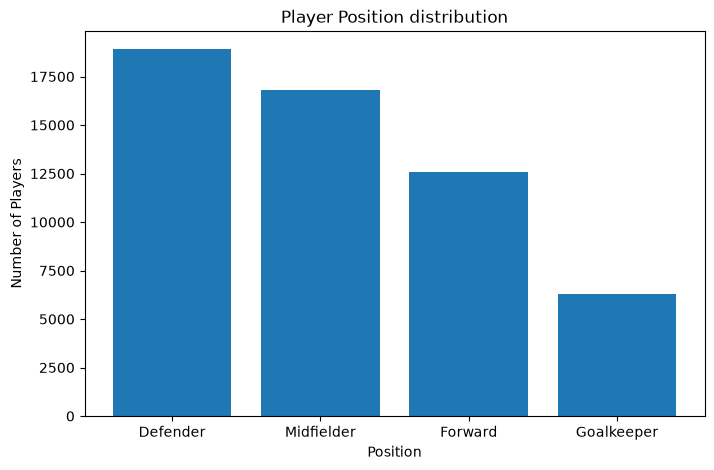

In [62]:
position_counts=df['position'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(position_counts.index,position_counts.values)
plt.title("Player Position distribution")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.show()

### Insight
This chart shows the distribution of players across different positions. The highest bar represents the most common playing position in the tournament.

### Top 10 Goal Scorers

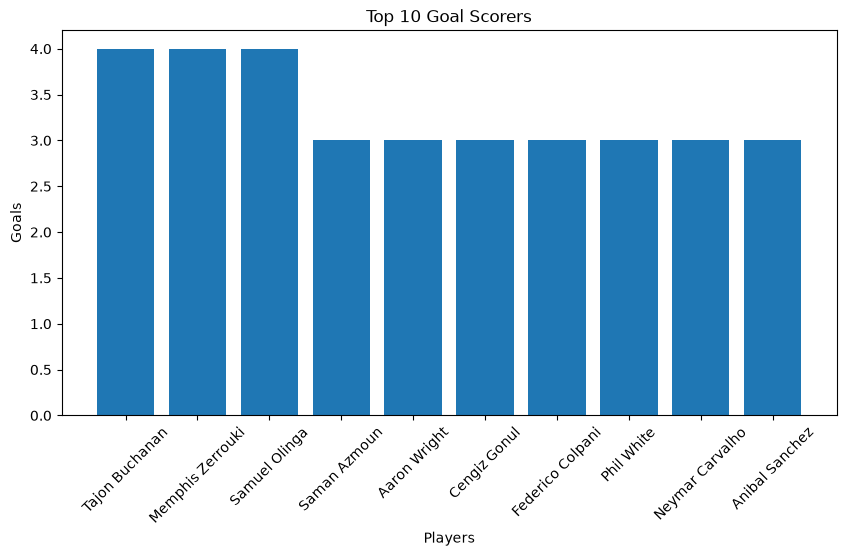

In [63]:
top_goals=df.nlargest(10,'goals')
plt.figure(figsize=(10,5))
plt.bar(top_goals['player_name'],top_goals['goals'])
plt.title("Top 10 Goal Scorers")
plt.xlabel("Players")
plt.ylabel("Goals")
plt.xticks(rotation=45)
plt.show()


### this chart highlights the top 10 goal scorers in the tournament.

## Preferred Foot Distribution
### Objective
This Visualization shows the percentage of players who prefer their left or right foot.

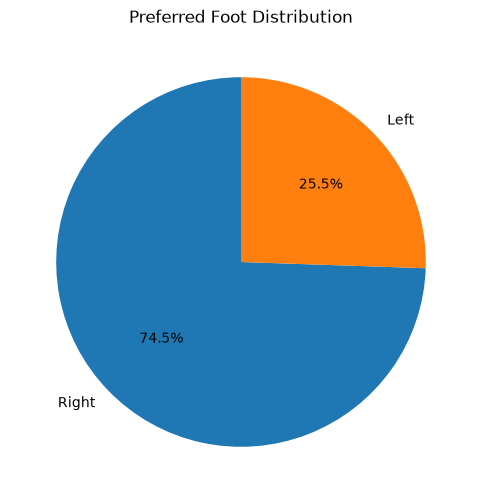

In [67]:
foot=df['preferred_foot'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    foot.values,
        labels=foot.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Preferred Foot Distribution")
plt.show()

### Insights
-This chart display the percentage of left-footed and right-footed players.
-It helps understand the dominant foot preference among players.

## 5. Age Distribution
### Objective
To understand the age distribution of players.

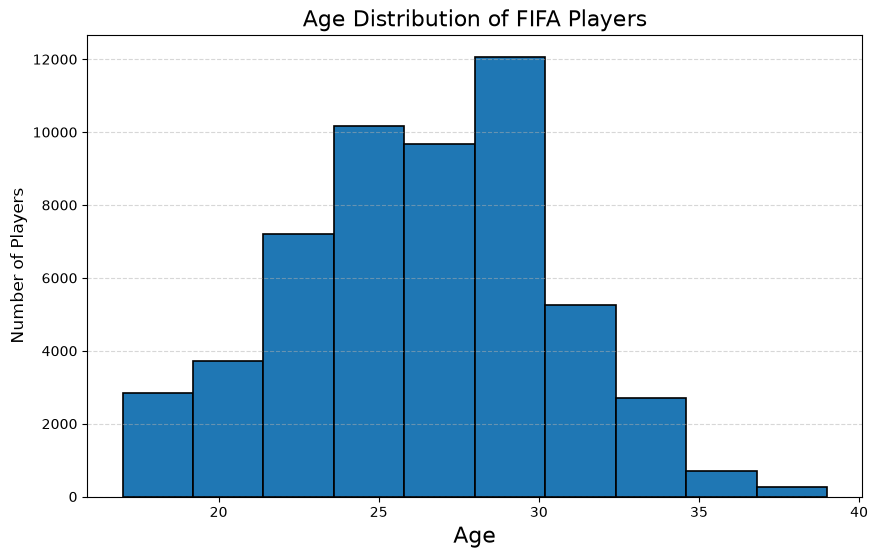

In [69]:
plt.figure(figsize=(10,6))
plt.hist(
    df['age'], bins=10,
edgecolor='black',
linewidth=1.2 )
plt.title("Age Distribution of FIFA Players", fontsize=16)
plt.xlabel("Age",fontsize=16)
plt.ylabel("Number of Players",fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

### Insights
-Most players are concentrated in the mid-age range.
-Very young and very old players are comparatively fewer.
The dataset indicates that teams generally that teams generally prefer players in their prime years.

## 6. Gosl Distribution
### Objective
To analyze how goals are distributed among FIFA world cup players.

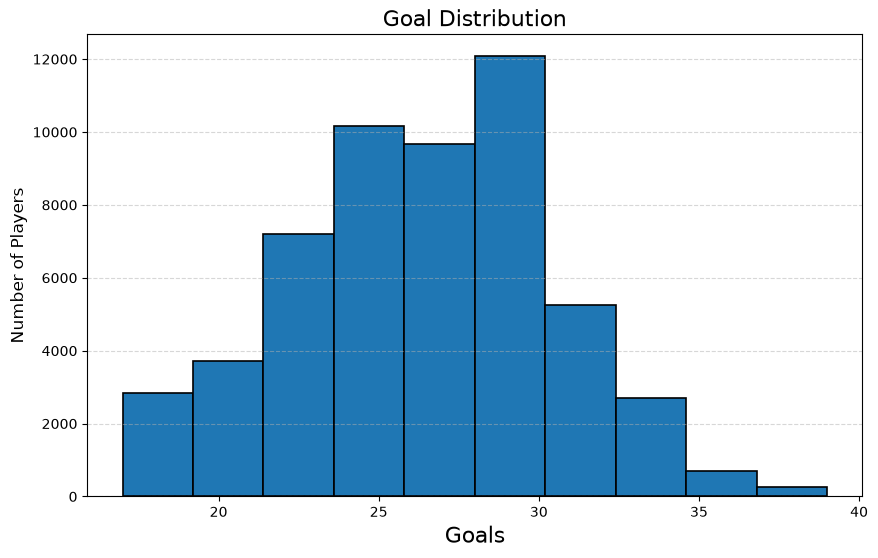

In [70]:
plt.figure(figsize=(10,6))
plt.hist(
    df['age'], bins=10,
edgecolor='black',
linewidth=1.2 )
plt.title("Goal Distribution", fontsize=16)
plt.xlabel("Goals",fontsize=16)
plt.ylabel("Number of Players",fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

### Insights
-Most players scored a small number of goals.
-Only a few players scored many goals.

## Height vs Weight Relationship
### Objective
To analyze the relationship between players's height and weight

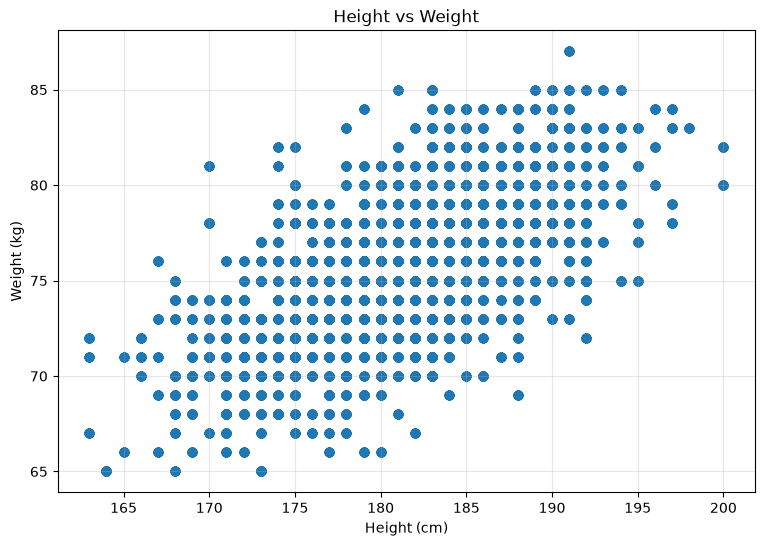

In [72]:
plt.figure(figsize=(9,6))
plt.scatter(
    df['height_cm'],
    df['weight_kg'],
    alpha=0.6
)
plt.title("Height vs Weight")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.grid(True, alpha=0.3)
plt.show()

### Insights
-Taller players generally have higher body weight
_A positive relationship can be observed between height and weight.

### Top Teams by Total Goals
## Objective
To identify the teams that scored the highest number of goals during the tournament.

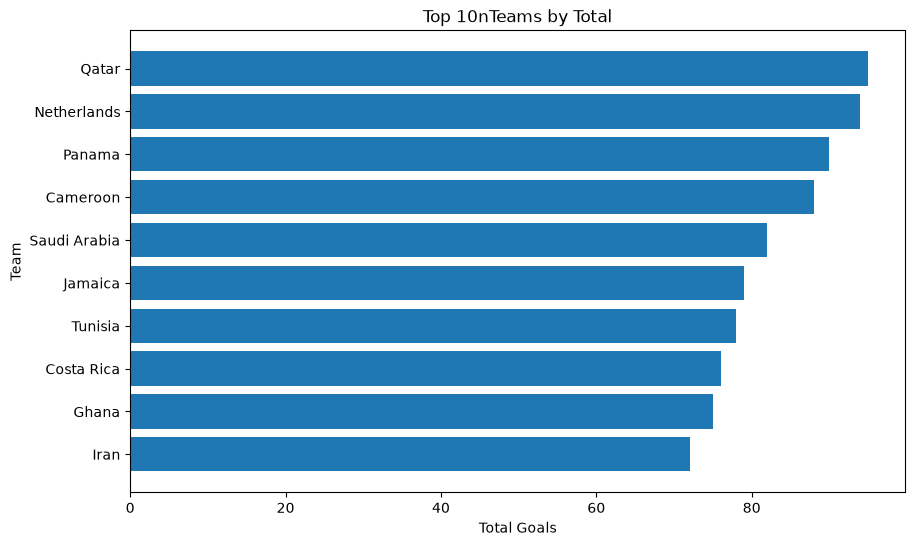

In [73]:
top_teams=(
    df.groupby('team')['goals'].sum().sort_values(ascending=False).head(10)
)
plt.figure(figsize=(10,6))
plt.barh(top_teams.index,top_teams.values)
plt.title("Top 10nTeams by Total")
plt.xlabel("Total Goals")
plt.ylabel("Team")
plt.gca().invert_yaxis()
plt.show()

### Insights
_ Show the top-performing teams based on total goals.
_ Helps compare attacking perfomance across teams.

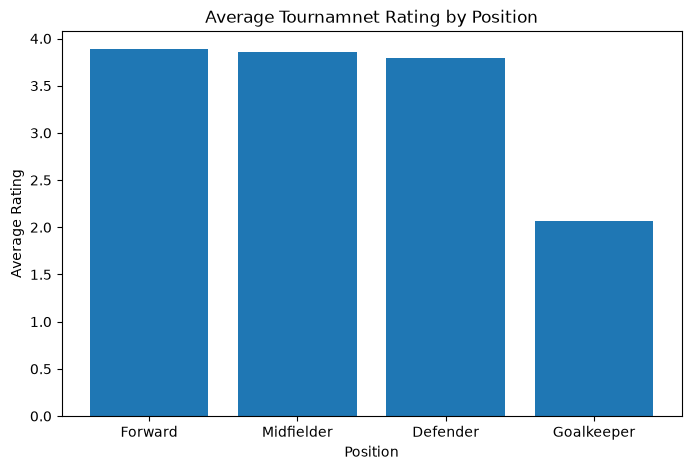

In [76]:
rating =(
    df.groupby('position')['tournament_rating'].mean().sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
plt.bar(rating.index, rating.values)
plt.title("Average Tournamnet Rating by Position")
plt.xlabel("Position")
plt.ylabel("Average Rating")
plt.show()

### Insights
-Identifies which position has the highest average rating
- Helps evaluate performance by player role

# Final Conclusion
This project involved cleaning, analyzing, and visualizing FIFA World Cup 2026 Player performance data using python, Data cleaning, EDA, and multiple visualizations were performed to uncover meaningful insights, about player performance, teams, positions, age, distribution and tournament ratings.

The cleaned dataset is now ready for SQL analysis and Power BI dashboard development

In [77]:
df.to_csv("../Dataset/fifa_Cleaned.csv", index=False)